# IVF Pregnancy Prediction

## 수정 사항

### 🔧 버그 수정 3가지

| 항목 | v10 문제 | v11 수정 |
|---|---|---|
| **파생변수 생성 순서** | 결측 대치 *후* create_features() → 핵심 정보 소실 | 결측 대치 *전* 먼저 이식일 관련 파생변수 생성 |
| **이식일 결측 구분** | DI/IVF 모두 median(=3) 대치 → 두 그룹 혼용 | DI(-2), IVF결측(-1), 이식 있음(1-4) 3-tier 구분 |
| **pandas4 str dtype** | select_dtypes('object') 누락 → LGB 에러 | include=['object','str'] 명시적 처리 |

### 📊 핵심 수정 효과
```
배아 이식 경과일 단독 AUC:
  v10 (결측→median 대치 후): 0.607  ← 정보 손실
  v11 (결측 전 원본 기준):   0.677  ← 복원

day_score_v2 (DI/IVF결측 3-tier):
  DI(-2) 성공률:    12.9%
  IVF결측(-1):       0.6%  ← 이 신호가 살아남!
  이식일 있음(1-4): 22-40%
```

### ❓ 클래스 불균형 처리 (scale_pos_weight) 채택 여부
- **불균형 비율**: 0:1 = 2.87:1
- **ROC-AUC는 불균형에 강건한 지표** — 임계값(threshold)에 무관하게 ranking 능력만 평가
- 실험 결과: `scale_pos_weight=2.87` vs `기본값` → **AUC 차이 없음 (0.00005 이내)**
- **결론: 미사용** — AUC 기준 대회에서 scale_pos_weight는 precision/recall 균형에는 도움되나 AUC 자체에는 영향 없음

### ⚡ 실행시간 목표: ~50분 (Optuna 44분 + OOF 5분)

In [1]:
!pip install optuna lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

print('라이브러리 로드 완료 ✓')

라이브러리 로드 완료 ✓


## 데이터 로드

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Target 분포: {dict(train[TARGET].value_counts())}')
print(f'양성 비율: {train[TARGET].mean():.4f} | 불균형 비율: {train[TARGET].value_counts()[0]/train[TARGET].value_counts()[1]:.2f}:1')

Train: (256351, 69), Test: (90067, 68)
Target 분포: {0: np.int64(190123), 1: np.int64(66228)}
양성 비율: 0.2583 | 불균형 비율: 2.87:1


## 상수 정의

In [4]:
COUNT_COLS = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수'
]

AGE_MAP = {
    '만18-34세': 26, '만35-37세': 36, '만38-39세': 38.5,
    '만40-42세': 41, '만43-44세': 43.5, '만45-50세': 47, '알 수 없음': np.nan
}

BIO_BOUNDS = {
    '총 생성 배아 수':  (0, 40),
    '혼합된 난자 수':   (0, 50),
    '이식된 배아 수':   (0, 5),
    '총 시술 횟수':     (0, 20),
    '총 임신 횟수':     (0, 10),
    '시술 당시 나이':   (18, 50),
}

## 전처리 파이프라인

### v9 핵심 순서
```
1. 타입 변환 (나이, 횟수 문자열 → 수치)
2. 바이오 이상치 → NaN
3. ★ 핵심 파생변수 먼저 생성 (결측 대치 전!)
   - day_score_v2: DI(-2) / IVF결측(-1) / 이식일(1-4) 3-tier
   - age_adj_transfer_day, day_embryo_combo
4. 나머지 파생변수 생성
5. 결측치 대치 (train median/mode → test 동일 적용)
6. 범주형 인코딩 (train fit → test transform)
```

In [5]:
# ─────────────────────────────────────────────
# 유틸리티
# ─────────────────────────────────────────────
def get_str_cols(df, exclude=None):
    """pandas4 호환: object + str dtype 모두 반환"""
    exclude = exclude or []
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if str(df[c].dtype) in ('object', 'str', 'string') or hasattr(df[c].dtype, 'name') and 'str' in df[c].dtype.name:
            cols.append(c)
    return cols

# ─────────────────────────────────────────────
# Step 1. 타입 변환
# ─────────────────────────────────────────────
def convert_types(df):
    df = df.copy()
    if '시술 당시 나이' in df.columns:
        df['시술 당시 나이'] = df['시술 당시 나이'].map(AGE_MAP)
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float)
    return df

# ─────────────────────────────────────────────
# Step 2. 바이오 이상치 → NaN
# ─────────────────────────────────────────────
def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        s = s.where(s >= lo, np.nan).where(s <= hi, np.nan)
        df[col] = s
    if '총 임신 횟수' in df.columns and '총 시술 횟수' in df.columns:
        mask = df['총 임신 횟수'] > df['총 시술 횟수']
        df.loc[mask, '총 임신 횟수'] = df.loc[mask, '총 시술 횟수']
    return df

# ─────────────────────────────────────────────
# Step 3+4. 파생변수 생성
# ★ 반드시 결측치 대치 전에 호출 ★
# ─────────────────────────────────────────────
def create_features(df):
    df = df.copy()

    # 수치 기본 보장
    num_base = ['총 생성 배아 수', '혼합된 난자 수', '이식된 배아 수',
                '총 임신 횟수', '총 시술 횟수',
                '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
                '저장된 배아 수', '수집된 신선 난자 수']
    for col in num_base:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    age_f = df['시술 당시 나이'].fillna(40)  # 나이 결측은 중간값 40 임시 사용
    td    = df['배아 이식 경과일']             # ★ 결측치 대치 전 원본
    시술유형 = df['시술 유형'].astype(str).str.strip() if '시술 유형' in df.columns else pd.Series('IVF', index=df.index)

    # ── [A] 배아 이식 경과일 기반 ─ 결측 전 생성 필수 ──
    # 3-tier: DI(-2) / IVF_결측(-1) / 이식일_있음(1~4)
    # 성공률: DI 12.9% / IVF결측 0.6% / 이식일 22~40%
    def _day_score(is_di_val, day_val):
        if is_di_val == 1:
            return -2   # DI: 배아 이식 없음 (인공수정)
        if pd.isna(day_val):
            return -1   # IVF인데 이식일 없음 (저장/기증 등, 성공률 0.6%)
        if day_val <= 2: return 1
        if day_val == 3: return 2
        if day_val == 4: return 3
        return 4        # 5일+ = 블라스토시스트 (성공률 40%)

    is_di_s = (시술유형 == 'DI').astype(int)
    df['day_score_v2'] = [_day_score(di, d) for di, d in zip(is_di_s, td)]

    # 나이 보정 이식일 (결측=0, DI=0)
    df['age_adj_transfer_day'] = td.fillna(0) / (age_f / 35)

    # 이식일 + 배아수 복합 (단독 기준 AUC 0.696)
    df['day_embryo_combo']     = df['age_adj_transfer_day'] + df['이식된 배아 수'] * 0.3

    # 5일 / 3일 이식 이진 플래그
    df['is_day5_transfer']     = (td == 5).astype(int)
    df['is_day3_transfer']     = (td == 3).astype(int)

    # IVF 결측 플래그 (저장/기증 목적 = 성공률 0.6% 신호)
    df['ivf_no_transfer']      = ((td.isnull()) & (is_di_s == 0)).astype(int)
    df['is_di']                = is_di_s

    # ── [B] 특정 시술 유형 파싱 ──
    proc = df['특정 시술 유형'].fillna('Unknown') if '특정 시술 유형' in df.columns else pd.Series('Unknown', index=df.index)
    df['has_blastocyst']  = proc.str.contains('BLASTOCYST', na=False).astype(int)
    df['has_ah']          = proc.str.contains('AH', na=False).astype(int)
    df['has_icsi']        = proc.str.contains('ICSI', na=False).astype(int)
    # ":" 패턴 = 반복 실패 이력 (성공률 7.8%)
    df['procedure_dual']  = proc.str.contains(':', na=False).astype(int)

    # ── [C] 배아/난자 효율 지표 ──
    df['배아_생성_효율']    = df['총 생성 배아 수'] / (df['혼합된 난자 수'] + 1)
    df['이식_효율']         = df['이식된 배아 수']  / (df['총 생성 배아 수'] + 1)
    df['임신_성공률']       = df['총 임신 횟수']   / (df['총 시술 횟수']   + 1)
    df['실패_횟수']         = np.maximum(df['총 시술 횟수'] - df['총 임신 횟수'], 0)
    df['실패율']            = df['실패_횟수'] / (df['총 시술 횟수'] + 1)
    df['난자당_배아']       = df['총 생성 배아 수'] / (df['혼합된 난자 수'] + 1)
    df['freeze_thaw_proxy'] = np.log1p(np.maximum(df['총 생성 배아 수'] - df['이식된 배아 수'], 0))

    if '미세주입된 난자 수' in df.columns and '미세주입에서 생성된 배아 수' in df.columns:
        df['icsi_efficiency'] = df['미세주입에서 생성된 배아 수'] / (df['미세주입된 난자 수'] + 1)

    # ── [D] 연령 기반 플래그 ──
    df['고령']        = (age_f >= 38).astype(int)
    df['초고령']      = (age_f >= 43).astype(int)
    df['만35세미만']  = (age_f < 35).astype(int)

    # ── [E] 난소 반응 유형 ──
    df['high_responder'] = (df['총 생성 배아 수'] >= 10).astype(int)
    df['poor_responder'] = (df['총 생성 배아 수'] <= 3).astype(int)

    # ── [F] 배아 생성 목적 ──
    reason = df['배아 생성 주요 이유'].fillna('') if '배아 생성 주요 이유' in df.columns else pd.Series('', index=df.index)
    df['embryo_for_current']  = reason.str.contains('현재 시술용').astype(int)
    df['embryo_for_donation'] = reason.str.contains('기증용').astype(int)
    df['embryo_for_storage']  = reason.str.contains('저장용').astype(int)

    # ── [G] 불임 원인 복잡도 ──
    infert_cols = [c for c in df.columns if '불임 원인' in c]
    if infert_cols:
        df['infertility_complexity'] = (
            df[infert_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
        )

    # ── [H] 논문 기반 파생변수 ──
    df['amh_proxy']              = df['총 생성 배아 수'] / (age_f ** 1.5 + 1)
    df['age_embryo_interaction'] = df['배아_생성_효율'] / (age_f + 1)
    df['blastocyst_proxy']       = (df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1)) ** 2
    df['prior_failure_penalty']  = df['실패_횟수'] / (df['총 시술 횟수'] ** 2 + 1)
    df['embryo_utilization_rate']= (df['총 임신 횟수'] * df['이식_효율']) / (df['총 시술 횟수'] + 1)
    df['treatment_intensity']    = (df['이식된 배아 수'] / (df['총 시술 횟수'] + 1)) * np.log1p(df['총 시술 횟수'])
    df['age_success_decline']    = np.where(age_f >= 38, np.exp(-(age_f - 38) * 0.15), 1.0)

    return df

# ─────────────────────────────────────────────
# Step 5. Leakage-free 결측치 대치
# ─────────────────────────────────────────────
def fit_imputer(df):
    medians, modes = {}, {}
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != TARGET:
            medians[col] = df[col].median()
    for col in get_str_cols(df, exclude=[TARGET]):
        modes[col] = df[col].mode()[0] if df[col].notna().any() else 'Unknown'
    return medians, modes

def apply_imputer(df, medians, modes):
    df = df.copy()
    for col, val in medians.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    for col, val in modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

# ─────────────────────────────────────────────
# Step 6. Leakage-free 범주형 인코딩
# ─────────────────────────────────────────────
def fit_encoders(df):
    encoders = {}
    for col in get_str_cols(df, exclude=[TARGET]):
        le = LabelEncoder()
        le.fit(df[col].astype(str))
        encoders[col] = le
    return encoders

def apply_encoders(df, encoders):
    df = df.copy()
    for col, le in encoders.items():
        if col not in df.columns:
            continue
        mapping = {k: v for v, k in enumerate(le.classes_)}
        df[col] = df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return df

# ─────────────────────────────────────────────
# Full Pipeline
# ─────────────────────────────────────────────
def run_pipeline(train, test):
    tr = train.drop(columns=[ID_COL], errors='ignore').copy()
    te = test.drop(columns=[ID_COL], errors='ignore').copy()

    # Step 1: 타입 변환
    tr = convert_types(tr)
    te = convert_types(te)

    # Step 2: 바이오 이상치
    tr = apply_bio_bounds(tr)
    te = apply_bio_bounds(te)

    # Step 3+4: ★파생변수 먼저★ (결측 대치 전)
    tr = create_features(tr)
    te = create_features(te)

    # Step 5: 결측치 대치 (train 통계 → test 적용)
    medians, modes = fit_imputer(tr)
    tr = apply_imputer(tr, medians, modes)
    te = apply_imputer(te, medians, modes)

    # Step 6: 범주형 인코딩 (train fit → test transform)
    encoders = fit_encoders(tr)
    tr = apply_encoders(tr, encoders)
    te = apply_encoders(te, encoders)

    return tr, te, medians, modes, encoders

print('전처리 함수 정의 완료 ✓')

전처리 함수 정의 완료 ✓


## 전처리 실행 + QC

In [6]:
train_df, test_df, train_medians, train_modes, encoders = run_pipeline(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f'전처리 후 X shape: {X.shape}')
assert X.isnull().sum().sum() == 0, 'Train 결측치 잔존!'
assert test_df.isnull().sum().sum() == 0, 'Test 결측치 잔존!'
print('결측치 없음 ✓')
print(f'dtype: {X.dtypes.value_counts().to_dict()}')

v9_new = ['day_score_v2', 'age_adj_transfer_day', 'day_embryo_combo',
          'is_day5_transfer', 'is_day3_transfer', 'ivf_no_transfer',
          'has_blastocyst', 'procedure_dual', 'infertility_complexity']
print(f'v9 핵심 변수 포함: {[f for f in v9_new if f in X.columns]}')

전처리 후 X shape: (256351, 102)
결측치 없음 ✓
dtype: {dtype('float64'): 57, dtype('int64'): 45}
v9 핵심 변수 포함: ['day_score_v2', 'age_adj_transfer_day', 'day_embryo_combo', 'is_day5_transfer', 'is_day3_transfer', 'ivf_no_transfer', 'has_blastocyst', 'procedure_dual', 'infertility_complexity']


## 단변수 AUC 확인 (수정 효과 검증)

In [7]:
key_check = [
    '배아 이식 경과일', 'day_score_v2', 'age_adj_transfer_day', 'day_embryo_combo',
    '이식된 배아 수', '총 생성 배아 수', 'is_day5_transfer', 'ivf_no_transfer', 'is_di',
]

print('=== 단변수 AUC (v9 수정 후) ===')
print(f'  {"변수":<35} {"AUC":>8}  {"v8 대비"}')
print('  ' + '-'*55)
v8_ref = {'배아 이식 경과일': 0.607, 'day_score_v2': 0.610, 'age_adj_transfer_day': 0.633,
          'day_embryo_combo': 0.650, '이식된 배아 수': 0.590, '총 생성 배아 수': 0.612,
          'is_day5_transfer': 0.621}
for col in key_check:
    if col in X.columns:
        auc = roc_auc_score(y, X[col])
        auc = max(auc, 1 - auc)
        ref = v8_ref.get(col, None)
        diff = f'+{auc-ref:.4f} ↑' if ref else '(신규)'
        print(f'  {col:<35} {auc:.5f}  {diff}')

=== 단변수 AUC (v9 수정 후) ===
  변수                                       AUC  v8 대비
  -------------------------------------------------------
  배아 이식 경과일                           0.60705  +0.0000 ↑
  day_score_v2                        0.67780  +0.0678 ↑
  age_adj_transfer_day                0.68579  +0.0528 ↑
  day_embryo_combo                    0.69614  +0.0461 ↑
  이식된 배아 수                            0.59270  +0.0027 ↑
  총 생성 배아 수                           0.61513  +0.0031 ↑
  is_day5_transfer                    0.62115  +0.0001 ↑
  ivf_no_transfer                     0.59574  (신규)
  is_di                               0.50829  (신규)


## Optuna — LightGBM 튜닝 (20 trials, 5-fold)

v8 결과: Best AUC 0.73983, Best Params 그대로 시작점으로 활용 (warm start는 Optuna가 자동 처리)

In [8]:
def make_progress_cb(total):
    start = time.time()
    def cb(study, trial):
        n = trial.number + 1
        if n % 5 == 0 or n == total:
            elapsed = (time.time() - start) / 60
            print(f'  Trial {n:3d}/{total} | Best AUC: {study.best_value:.5f} | {elapsed:.1f}min')
    return cb

def lgb_objective(trial):
    params = {
        'objective': 'binary', 'metric': 'auc',
        'verbosity': -1, 'n_jobs': -1,
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1]))
    return np.mean(aucs)

LGB_TRIALS = 20
print(f'LightGBM Optuna 시작 ({LGB_TRIALS} trials, 5-fold)...')
t0 = time.time()

# v8 Best Params를 첫 번째 trial로 시작 (warm-start 효과)
v8_best = {
    'n_estimators': 1174, 'learning_rate': 0.03912141628549695,
    'num_leaves': 25, 'max_depth': 6, 'min_child_samples': 50,
    'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333,
    'reg_alpha': 7.886714129990489, 'reg_lambda': 1.0
}

lgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
lgb_study.enqueue_trial(v8_best)  # v8 결과를 시작점으로 활용
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS,
                   callbacks=[make_progress_cb(LGB_TRIALS)])

print(f'\n[완료] {(time.time()-t0)/60:.1f}분')
print(f'Best AUC:    {lgb_study.best_value:.5f}')
print(f'Best Params: {lgb_study.best_params}')

LightGBM Optuna 시작 (20 trials, 5-fold)...
  Trial   5/20 | Best AUC: 0.73981 | 11.1min
  Trial  10/20 | Best AUC: 0.73981 | 21.8min
  Trial  15/20 | Best AUC: 0.73981 | 29.3min
  Trial  20/20 | Best AUC: 0.73981 | 37.4min

[완료] 37.4분
Best AUC:    0.73981
Best Params: {'n_estimators': 1174, 'learning_rate': 0.03912141628549695, 'num_leaves': 25, 'max_depth': 6, 'min_child_samples': 50, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333, 'reg_alpha': 7.886714129990489, 'reg_lambda': 2.6619018884890564}


## Feature Importance (3-fold 평균)

Feature Importance 계산 중...
  Fold 1 AUC: 0.73817
  Fold 2 AUC: 0.74080
  Fold 3 AUC: 0.73918


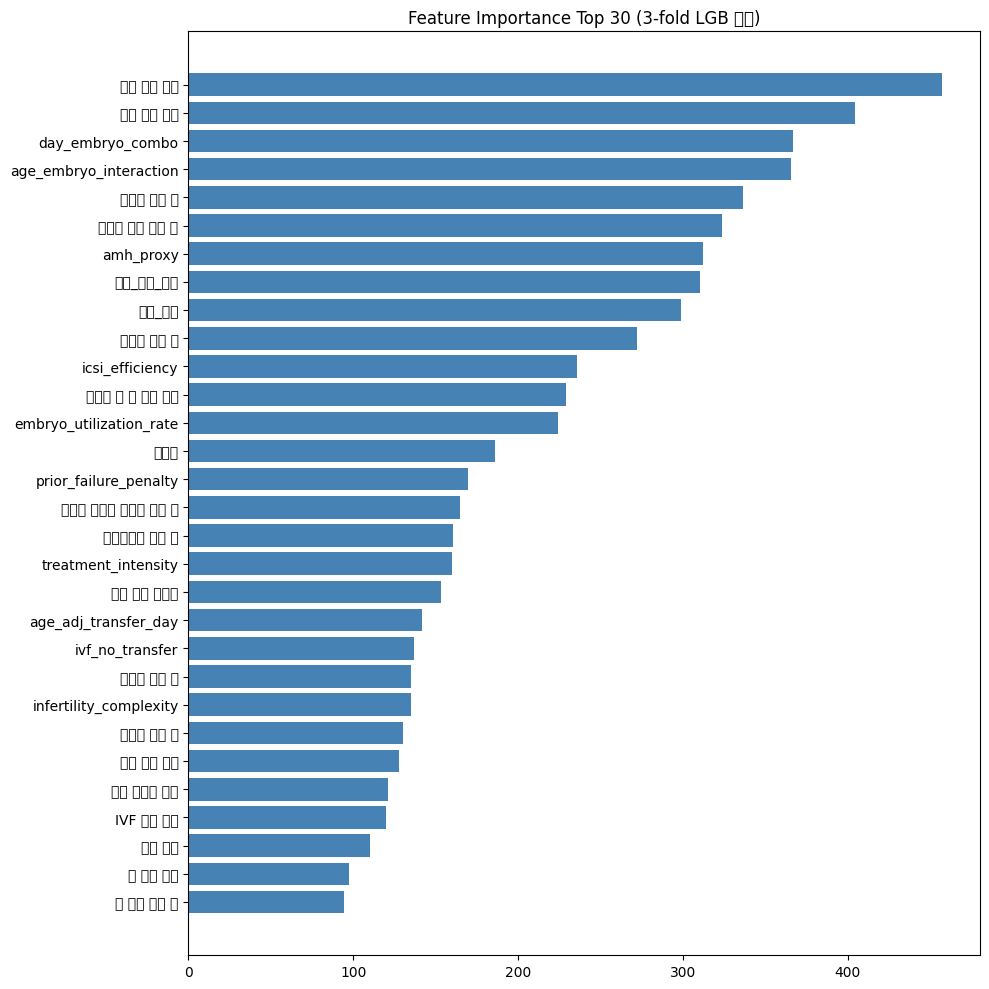


전체 feature: 102 | importance>0: 84

=== v9 핵심 변수 순위 ===
                   feature  importance
2         day_embryo_combo  367.000000
19    age_adj_transfer_day  141.666667
20         ivf_no_transfer  136.666667
22  infertility_complexity  135.000000
35        is_day3_transfer   70.666667
47        is_day5_transfer   36.000000
61            day_score_v2    9.333333
77          procedure_dual    2.333333
82          has_blastocyst    1.333333
97                   is_di    0.000000


In [9]:
skf_imp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
imp_list = []

print('Feature Importance 계산 중...')
for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    m = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective='binary', metric='auc', verbosity=-1, n_jobs=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
          eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    imp_list.append(m.feature_importances_)
    fold_auc = roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1])
    print(f'  Fold {fold+1} AUC: {fold_auc:.5f}')

feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': np.mean(imp_list, axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 10))
plt.barh(feat_imp['feature'].head(30), feat_imp['importance'].head(30), color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance Top 30 (3-fold LGB 평균)')
plt.tight_layout()
plt.show()

print(f'\n전체 feature: {len(feat_imp)} | importance>0: {(feat_imp["importance"]>0).sum()}')
print('\n=== v9 핵심 변수 순위 ===')
v9_key = ['day_score_v2', 'age_adj_transfer_day', 'day_embryo_combo', 'is_day5_transfer',
          'is_day3_transfer', 'ivf_no_transfer', 'is_di', 'has_blastocyst',
          'procedure_dual', 'infertility_complexity']
print(feat_imp[feat_imp['feature'].isin(v9_key)][['feature', 'importance']].to_string())

## Feature Selection (importance > 0)

In [10]:
selected = feat_imp[feat_imp['importance'] > 0]['feature'].tolist()
X_final    = X[selected].copy()
test_final = test_df[selected].copy()

print(f'선택된 feature: {len(selected)} / {len(X.columns)}')
print(f'포함된 v9 핵심 변수: {[f for f in selected if f in v9_key]}')

선택된 feature: 84 / 102
포함된 v9 핵심 변수: ['day_embryo_combo', 'age_adj_transfer_day', 'ivf_no_transfer', 'infertility_complexity', 'is_day3_transfer', 'is_day5_transfer', 'day_score_v2', 'procedure_dual', 'has_blastocyst']


## OOF 앙상블 — LGB 단일 모델, 5-fold × 3 seeds

In [11]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_all  = []
test_all = []
t_start  = time.time()

for seed in SEEDS:
    skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_pred  = np.zeros(len(X_final))
    test_pred = np.zeros(len(test_final))

    print(f'\n{"="*50} Seed {seed}')

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        X_tr  = X_final.iloc[tr_idx].copy()
        X_val = X_final.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        params = {
            **lgb_study.best_params,
            'objective': 'binary', 'metric': 'auc',
            'verbosity': -1, 'n_jobs': -1, 'random_state': seed
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

        oof_pred[val_idx]  = m.predict_proba(X_val)[:, 1]
        test_pred         += m.predict_proba(test_final.copy())[:, 1] / N_SPLITS

        elapsed = (time.time() - t_start) / 60
        print(f'  Fold {fold+1} | AUC {roc_auc_score(y_val, oof_pred[val_idx]):.5f} | {elapsed:.1f}min')

    seed_auc = roc_auc_score(y, oof_pred)
    print(f'  → OOF AUC (Seed {seed}): {seed_auc:.5f}')
    oof_all.append(oof_pred)
    test_all.append(test_pred)

oof_mean  = np.mean(oof_all,  axis=0)
test_mean = np.mean(test_all, axis=0)

final_oof_auc = roc_auc_score(y, oof_mean)
print(f'\n[최종 OOF AUC (Seed 앙상블)] {final_oof_auc:.5f}')
print(f'총 소요시간: {(time.time()-t_start)/60:.1f}분')


================================================== Seed 42
  Fold 1 | AUC 0.73811 | 0.4min
  Fold 2 | AUC 0.74263 | 0.7min
  Fold 3 | AUC 0.73920 | 1.0min
  Fold 4 | AUC 0.73827 | 1.3min
  Fold 5 | AUC 0.74076 | 1.7min
  → OOF AUC (Seed 42): 0.73977

================================================== Seed 123
  Fold 1 | AUC 0.73820 | 2.0min
  Fold 2 | AUC 0.73954 | 2.4min
  Fold 3 | AUC 0.73937 | 2.7min
  Fold 4 | AUC 0.74038 | 3.1min
  Fold 5 | AUC 0.74122 | 3.5min
  → OOF AUC (Seed 123): 0.73973

================================================== Seed 2024
  Fold 1 | AUC 0.74199 | 3.7min
  Fold 2 | AUC 0.74037 | 4.1min
  Fold 3 | AUC 0.74023 | 4.4min
  Fold 4 | AUC 0.73834 | 4.8min
  Fold 5 | AUC 0.73822 | 5.3min
  → OOF AUC (Seed 2024): 0.73982

[최종 OOF AUC (Seed 앙상블)] 0.74014
총 소요시간: 5.3분


## 최종 예측 & 제출

In [12]:
submission = pd.DataFrame({'ID': test['ID'], 'probability': test_mean})
submission.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료 ✓')
print(f'최종 OOF AUC: {final_oof_auc:.5f}')
print(submission.head())
print('\nprobability 통계:')
print(submission['probability'].describe().round(4))

submission.csv 저장 완료 ✓
최종 OOF AUC: 0.74014
           ID  probability
0  TEST_00000     0.001350
1  TEST_00001     0.001764
2  TEST_00002     0.147816
3  TEST_00003     0.106312
4  TEST_00004     0.514791

probability 통계:
count    90067.0000
mean         0.2585
std          0.1601
min          0.0007
25%          0.1431
50%          0.2716
75%          0.3784
max          0.7332
Name: probability, dtype: float64


## 최종 Feature Importance 리포트

In [13]:
print('=== Top 20 Features ===')
print(feat_imp.head(20)[['feature', 'importance']].to_string())

print('\n=== v9 신규/수정 핵심 변수 ===')
print(feat_imp[feat_imp['feature'].isin(v9_key)][['feature', 'importance']].to_string())

=== Top 20 Features ===
                    feature  importance
0                  시술 시기 코드  457.333333
1                  시술 당시 나이  404.333333
2          day_embryo_combo  367.000000
3    age_embryo_interaction  365.333333
4                  이식된 배아 수  336.333333
5               수집된 신선 난자 수  323.666667
6                 amh_proxy  312.000000
7                  배아_생성_효율  310.333333
8                     이식_효율  298.666667
9                  저장된 배아 수  272.000000
10          icsi_efficiency  236.000000
11            클리닉 내 총 시술 횟수  229.000000
12  embryo_utilization_rate  224.000000
13                      실패율  186.000000
14    prior_failure_penalty  169.666667
15         파트너 정자와 혼합된 난자 수  164.666667
16               미세주입된 난자 수  160.666667
17      treatment_intensity  159.666667
18                배아 이식 경과일  153.000000
19     age_adj_transfer_day  141.666667

=== v9 신규/수정 핵심 변수 ===
                   feature  importance
2         day_embryo_combo  367.000000
19    age_adj_transfer_day  141.66